In [ ]:
# Imports
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# Function
def preprocess_frame(frame):
        preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
                             ])
        return preprocess(frame)

In [3]:
# Model
num_classes = 1081
resnet_checkpoint_path = 'models/resnet50_weights_best_acc.tar'

model = resnet50(num_classes=num_classes)
checkpoint = torch.load(resnet_checkpoint_path, map_location='cpu')
state_dict = checkpoint["model"]

model = resnet50(num_classes=num_classes)
model.load_state_dict(state_dict=state_dict, strict=True)
model = torch.nn.Sequential(*(list(model.children())[:-1]))
model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [4]:
# Datasets
dataset1 = "data/frames/biodiverse_a/"
frames1 = os.listdir(dataset1)

dataset2 = "data/frames/grass_a/"
frames2 = os.listdir(dataset2)

dataset3 = "data/frames/grass_long/"
frames3 = os.listdir(dataset3)

dataset4 = "data/frames/grass/"
frames4 = os.listdir(dataset4)

In [5]:
# Embeddings
embeddings = []
labels = []

for frame in frames1:
    img = Image.open(dataset1 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.cpu().numpy().flatten())
    labels.append('green')

for frame in frames2:
    img = Image.open(dataset2 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.cpu().numpy().flatten())
    labels.append('red')

for frame in frames3:
    img = Image.open(dataset3 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.cpu().numpy().flatten())
    labels.append('green')

for frame in frames4:
    img = Image.open(dataset4 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.cpu().numpy().flatten())
    labels.append('red')

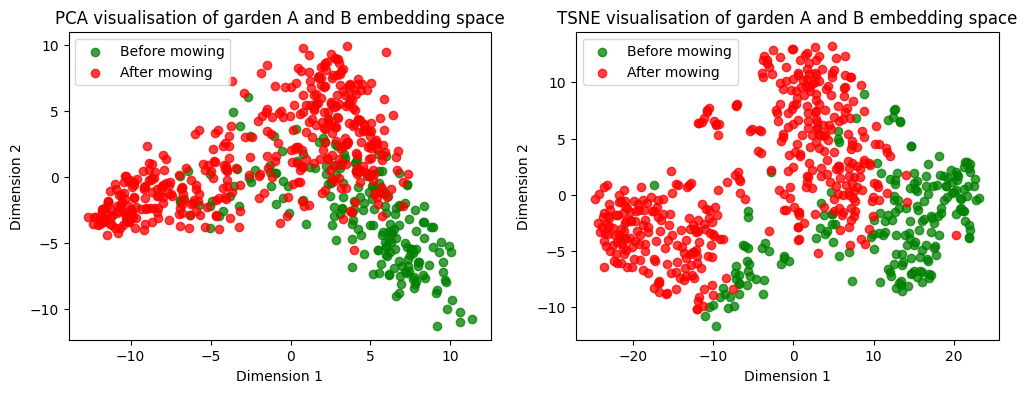

In [6]:
# Visualisation
embeddingspace = np.array(embeddings)

pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(embeddingspace)

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_results = tsne.fit_transform(embeddingspace)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_map = {
    'green': 'Before mowing',
    'red': 'After mowing'
}

# PCA plot
for color, dataset_name in color_map.items():
    idxs = [i for i, lbl in enumerate(labels) if lbl == color]
    axes[0].scatter(
        pca_results[idxs, 0], 
        pca_results[idxs, 1], 
        c=color, 
        alpha=0.75, 
        label=dataset_name
    )
axes[0].set_title("PCA visualisation of garden A and B embedding space")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")
axes[0].legend()

# t-SNE plot
for color, dataset_name in color_map.items():
    idxs = [i for i, lbl in enumerate(labels) if lbl == color]
    axes[1].scatter(
        tsne_results[idxs, 0], 
        tsne_results[idxs, 1], 
        c=color, 
        alpha=0.75, 
        label=dataset_name
    )
axes[1].set_title("TSNE visualisation of garden A and B embedding space")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
axes[1].legend()

plt.show()